<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Análise e projeto de vigas sujeitas à flexão. Diagramas de esforços internos.

### Problema 4

A viga representada na figura suporta uma carga distribuída Q, uma carga concentrada $F_B$ e um momento $M_A$.

a) Determine as reações no apoio C e represente os diagramas de esforço transverso e momento fletor.

b) Considere agora que o momento $M_A$ pode variar e determine o valor de $M_A$ que minimiza o momento máximo na viga.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P4/MSII_Au04_P4.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução


In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

dados = varin()
dados.MA = 15. # unit: kN.m
dados.FB = 30. # unit: kN
dados.Q = 7.5 # unit: kN/m (em módulo)
dados.LAB = 1. # unit: m
dados.LBC = 4. # unit: m
dados.LAC = dados.LAB + dados.LBC

#### a) Escreva as equações do esforço transverso e do momento fletor em toda a viga e trace os diagramas desses esforços.

Para a determinação dos diagramas de esforços é necessário:
- Defenir o diagrama de corpo livre da viga (DCL)
- Determinar as forças desconhecidada no DCL, ou seja, determinar as forças de reação, da ligação da viga ao exterior
- Aplicar o método das secções ao longo dos troços relevantes no problema; neste caso os tramso AB e BC.
  
##### Cálculo das reacções

In [2]:
Qeq = dados.Q*dados.LAC
xQeq = dados.LAC/2

print('Equations from Statics:\n-----------------------')
cy, my = sy.symbols('cy my')
sumFy = dados.FB - Qeq + cy
print(f'sumFy = 0 : {sumFy} = 0 [kN] ')
sumMC = dados.MA - dados.FB*dados.LBC + Qeq*xQeq + my
print(f'sumMA = 0 ; {sumMC} = 0 [kN.m]')
sol = solve({sumFy,sumMC},{cy, my})

print('Reactions:\n---------')
CY = sol[cy]; print(f'Cy = {CY:.1f}   [kN]')
MY = sol[my]; print(f'My = {MY:.2f} [kN.m]')

Equations from Statics:
-----------------------
sumFy = 0 : cy - 7.5 = 0 [kN] 
sumMA = 0 ; my - 11.25 = 0 [kN.m]
Reactions:
---------
Cy = 7.5   [kN]
My = 11.25 [kN.m]


#### Troço AB :: $x\in [x_A,x_B[$

- Esforço transverso:

\begin{equation*}
V_A - \int_{x_A}^x w_{AB}(t)~\mathrm{d}t - V_{AB}(x) = 0
\end{equation*}

- Momento fletor:

\begin{equation*}
M_A + \overline{Q}(x-\overline{x}) + M_{AB}(x) = 0
\end{equation*}

com,

\begin{equation*}
\overline{Q} = \int_{x_A}^x w_{AB}(t)~\mathrm{d}t
\quad\wedge\quad
\overline{x} = \frac{\int_{x_A}^x w_{AB}(t)~t~\mathrm{d}t}{\overline{Q}}
\end{equation*}

ou, de forma mais direta e simples,

\begin{equation*}
M_A + Q \cdot x \left(\frac{x}{2}\right) + M_{AB}(x) = 0
\end{equation*}


In [3]:
vab, mab, x = sy.symbols('vab mab x')

VA = 0 # free edge
wab = dados.Q
i1ab = sy.integrate(wab, (x,0,x))
sumFyab = VA - i1ab - vab

MA = dados.MA
fQab = dados.Q*x # integrant function
i2ab = sy.integrate(fQab, (x,0,x))
sumMab = MA + i1ab*(x-i2ab/i1ab) + mab

print('------------------------------------')
print('Equilibrium equations:')
print('------------------------------------')
print('sumFyab = ',sumFyab)
print('sumMab  = ',sumMab)

------------------------------------
Equilibrium equations:
------------------------------------
sumFyab =  -vab - 7.5*x
sumMab  =  mab + 3.75*x**2 + 15.0


In [4]:
sol = solve({sumFyab,sumMab},{vab, mab})

print('------------------------------------')
print('Section AB:')
print('------------------------------------')
VAB = sol[vab]; print(f'Esforço Transverso, V(x) = {VAB} [N]')
MAB = sol[mab]; print(f'Momento fletor, M(x) = {MAB} [N.m]')

print('\n --- Valores nos extremos do intervalo: --')
VAB_A = VAB.subs({(x,0)})
print(f'VAB(x=0)   = {VAB_A} [N]')
VAB_B = VAB.subs({(x,dados.LAB)})
print(f'VAB(x=LAB) = {VAB_B:.1f} [N]')

MAB_A = MAB.subs({(x,0)})
print(f'MAB(x=0)   = {MAB_A:.1f} [N.m]')
MAB_B = MAB.subs({(x,dados.LAB)})
print(f'MAB(x=LAB) = {MAB_B:.1f} [N.m]')

------------------------------------
Section AB:
------------------------------------
Esforço Transverso, V(x) = -7.5*x [N]
Momento fletor, M(x) = -3.75*x**2 - 15.0 [N.m]

 --- Valores nos extremos do intervalo: --
VAB(x=0)   = 0 [N]
VAB(x=LAB) = -7.5 [N]
MAB(x=0)   = -15.0 [N.m]
MAB(x=LAB) = -18.8 [N.m]


#### Troço BC :: $x\in [x_B,x_C[$

- Esforço transverso:

\begin{equation*}
V_{BC}(x) = V_B - \int_{x_B}^x w_{BC}(t)~\mathrm{d}t
~\wedge~
V_B = V_{AB}(x_{B}) + F_B
\end{equation*}

- Momento fletor:

\begin{equation*}
M_{BC}(x) = M_B + \int_{x_B}^x V_{BC}(t)~\mathrm{d}t
~\wedge~
M_B = M_{AB}(x_{B})
\end{equation*}

In [5]:
vbc, mbc = sy.symbols('vbc mbc')

VB = VAB_B + dados.FB # free edge
wbc = dados.Q
i1bc = sy.integrate(wbc, (x,dados.LAB,x))
VBC = VB - i1bc

MB = MAB_B
iVbc = sy.integrate(VBC, (x,dados.LAB,x))
MBC = MAB_B + iVbc

print('------------------------------------')
print('Section BC:')
print('------------------------------------')
print(f'Esforço Transverso, V(x) = {VBC} [N]')
print(f'Momento fletor, M(x) = {MBC} [N.m]')

print('\n --- Valores nos extremos do intervalo: --')
VBC_B = VBC.subs({(x,dados.LAB)})
print(f'VBC(x=LAB) = {VBC_B:.1f} [N]')
VBC_C = VBC.subs({(x,dados.LAC)})
print(f'VBC(x=LBC) = {VBC_C:.1f} [N]')

MBC_B = MBC.subs({(x,dados.LAB)})
print(f'MBC(x=LAB) = {MBC_B:.1f} [N.m]')
MBC_C = MBC.subs({(x,dados.LAC)})
print(f'MBC(x=LBC) = {MBC_C:.1f} [N.m]')

------------------------------------
Section BC:
------------------------------------
Esforço Transverso, V(x) = 30.0 - 7.5*x [N]
Momento fletor, M(x) = -3.75*x**2 + 30.0*x - 45.0 [N.m]

 --- Valores nos extremos do intervalo: --
VBC(x=LAB) = 22.5 [N]
VBC(x=LBC) = -7.5 [N]
MBC(x=LAB) = -18.8 [N.m]
MBC(x=LBC) = 11.2 [N.m]


#### Diagrama de Esforço Transverso

--------------------------------
Troço BC: Momento fletor máximo
--------------------------------
VCD(x) = 0 :: x (in BC) = 4.0 m | x (global) = 5.0 m
Mmax(x.V=0)  =  15.0  kN.m
max(Mplot)   =  15.0  kN.m (verification)


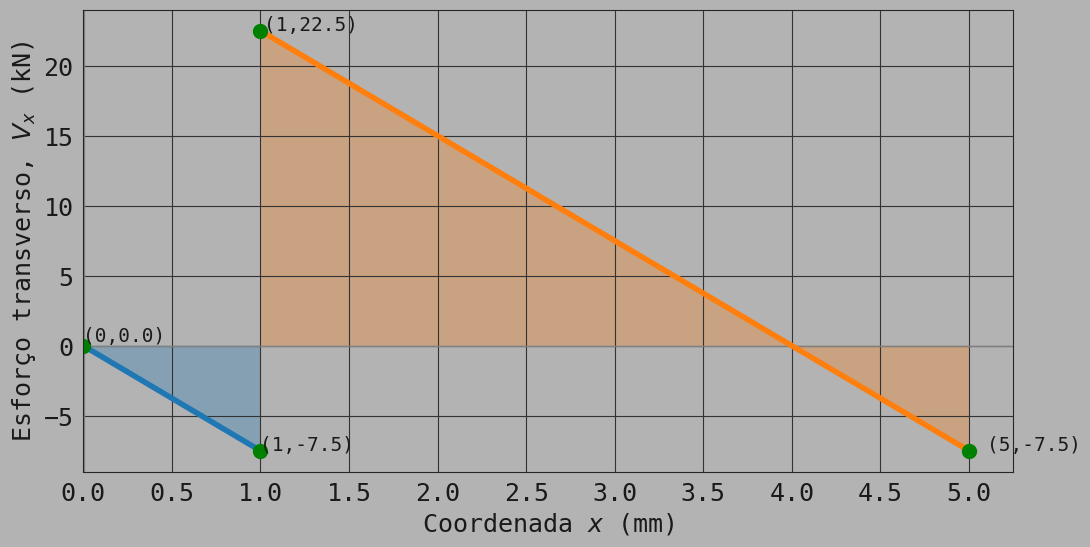

In [6]:
xAB = np.linspace(0,dados.LAB)
xBC = np.linspace(dados.LAB,dados.LAC)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB, yMAB = sy2array(VAB,xAB), sy2array(MAB,xAB)

# BC
yVBC, yMBC = sy2array(VBC,xBC), sy2array(MBC,xBC)

print('--------------------------------')
print('Troço BC: Momento fletor máximo')
print('--------------------------------')
sol1 = solve(VBC,x)
xVbc0l = sol1[0]
xVbc0g = dados.LAB + xVbc0l
print(f'VCD(x) = 0 :: x (in BC) = {xVbc0l:.1f} m | x (global) = {xVbc0g:.1f}'
      f' m')
Mmax = MBC.subs(x,xVbc0l)
print('Mmax(x.V=0)  = ','{:.1f}'.format(Mmax),' kN.m')
print('max(Mplot)   = ','{:.1f}'.format(np.max(yMBC)),' kN.m (verification)')

# PLOTS
fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0],yVAB[0]+.3,f'({xAB[0]:.0f},{yVAB[0]:.1f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yVAB[-1]*1.,f'({xAB[-1]:.0f},{yVAB[-1]:.1f})',
         fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*1.02,yVBC[0]*1.,f'({xBC[0]:.0f},{yVBC[0]:.1f})',
         fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.02,yVBC[-1]*1.,f'({xBC[-1]:.0f},{yVBC[-1]:.1f})',
         fontsize=fz)
plt.xlim(0,dados.LAC*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,dados.LAC*1.1, 0.5),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

#### Diagrama de Momento Fletor

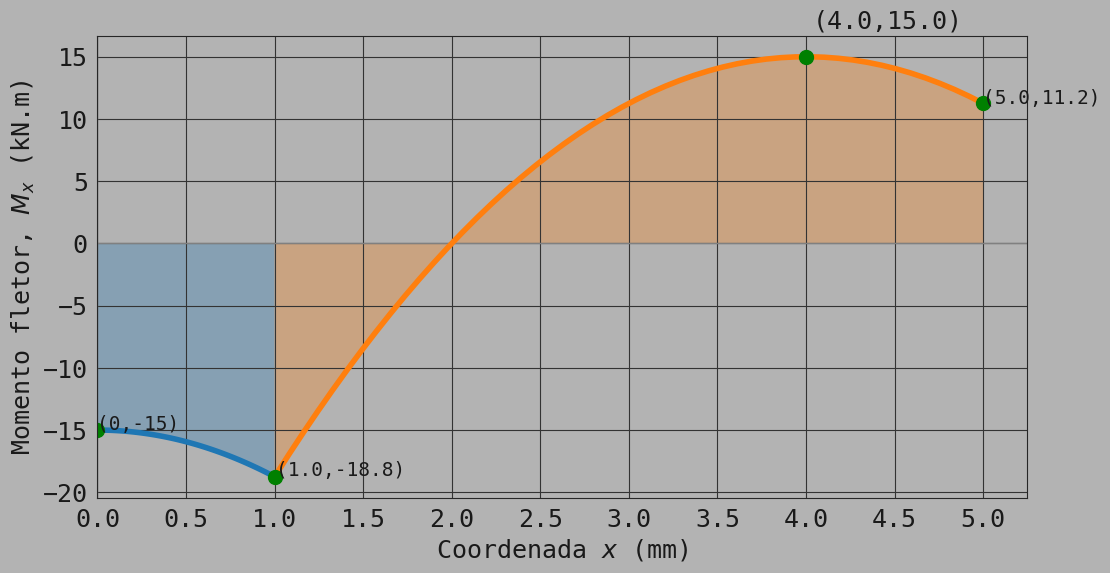

In [7]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0]*1.,yMAB[0],f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.text(xAB[-1]+.01,yMAB[-1]+.1,f'({xAB[-1]:.1f},{yMAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.,yMBC[-1]*1.,f'({xBC[-1]:.1f},{yMBC[-1]:.1f})',fontsize=fz)
x0, y0 = xVbc0l, MBC.subs(x,xVbc0l)
plt.text(x0*1.01,y0*1.15,f'({x0:.1f},{y0:.1f})',fontsize=18)
plt.plot(x0,y0,'go',markersize=10)
plt.xlim(0,dados.LAC*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,dados.LAC*1.1, 0.5),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

#### b) Considere agora que o momento $M_A$ pode variar e determine o valor de $M_A$ que minimiza o momento máximo na viga.

A viga é solicitada por um sistema de forças (distribuída e pontual) e pelo momento $M_A$. Desta forma, pelo princípio da sobreposição, o diagrama de momentos fletores pode ser separado entre o efeito devido às forças aplicadas (fixo) e o efeito devido ao momento fletor.  

Pelo princípio da sobreposição considere-se a : 

- (i) diagrama de momento fletor devido ao carregamneto real, sem momento $M_A$.
- (ii) diagrama de momento fletor correspondente à aplicação do momento fletor $M_A$. Nota: este diagrama é constante ao longo da vida e de magnitude igual a $M_A$.

No primeiro cenário de carregamento (para o qual $M_A$ = 0 kN.m), obtêm-se os seguintes diagramas de esforços:

----------------------------
Section AB:
----------------------------
Momento fletor, M(x) = -3.75*x**2 [N.m]
--- Valores nos extremos do intervalo: --
(b) MAB(x=0)   = 0 [N.m]
(b) MAB(x=LAB) = -3.75 [N.m]
----------------------------
Section BC:
----------------------------
Momento fletor, M(x) = -3.75*x**2 + 30.0*x - 30.0 [N.m]
--- Valores nos extremos do intervalo: --
(b) MBC(x=LAB) = -3.75 [N.m]
(b) MBC(x=LBC) = 26.25 [N.m]
--------------------------------
Troço BC: Momento fletor máximo
--------------------------------
(b) Mmax(x.V=0)  =  30.0  kN.m
(b) max(Mplot)   =  30.0  kN.m (verification)


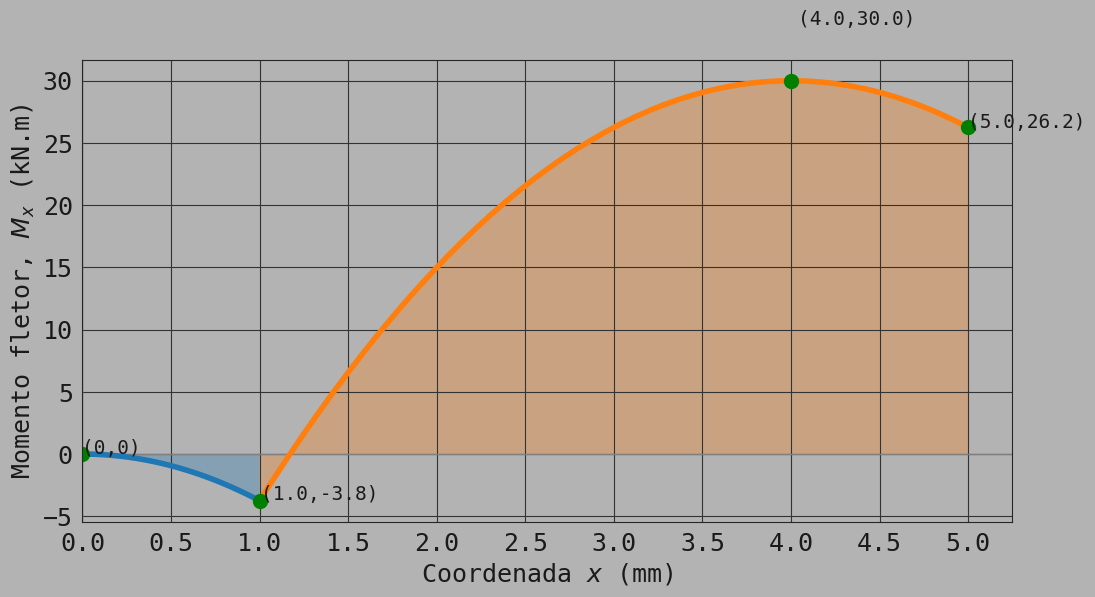

In [8]:
MA = 0

def madim(MA):

    MAB_b = - MA - i1ab*(x-i2ab/i1ab)
    print('----------------------------')
    print('Section AB:')
    print('----------------------------')
    print(f'Momento fletor, M(x) = {MAB_b} [N.m]')

    print('--- Valores nos extremos do intervalo: --')
    MAB_A_b = MAB_b.subs({(x,0)})
    print(f'(b) MAB(x=0)   = {MAB_A_b} [N.m]')
    MAB_B_b = MAB_b.subs({(x,dados.LAB)})
    print(f'(b) MAB(x=LAB) = {MAB_B_b:.2f} [N.m]')

    MBC_b = MAB_B_b + iVbc
    print('----------------------------')
    print('Section BC:')
    print('----------------------------')
    print(f'Momento fletor, M(x) = {MBC_b} [N.m]')
    print('--- Valores nos extremos do intervalo: --')
    MBC_B_b = MBC_b.subs({(x,dados.LAB)})
    print(f'(b) MBC(x=LAB) = {MBC_B_b:.2f} [N.m]')
    MBC_C_b = MBC_b.subs({(x,dados.LAC)})
    print(f'(b) MBC(x=LBC) = {MBC_C_b:.2f} [N.m]')

    # AB
    yMAB_b = sy2array(MAB_b,xAB) #

    # BC
    yMBC_b = sy2array(MBC_b,xBC) #

    print('--------------------------------')
    print('Troço BC: Momento fletor máximo')
    print('--------------------------------')
    Mmax_b = MBC_b.subs(x,xVbc0l)
    print('(b) Mmax(x.V=0)  = ','{:.1f}'.format(Mmax_b),' kN.m')
    print('(b) max(Mplot)   = ','{:.1f}'.format(np.max(yMBC_b)),' kN.m (verification)')

    # PLOTS

    fig, ax = plt.subplots(figsize=(12,6))
    plt.axhline(linewidth=1,color=(.5, .5, .5))
    plt.axvline(linewidth=1,color=(.5, .5, .5))
    plt.plot(xAB,yMAB_b,linewidth=4)
    plt.fill_between(xAB,yMAB_b, alpha=.3)
    plt.plot(xBC,yMBC_b,linewidth=4)
    plt.fill_between(xBC,yMBC_b, alpha=.3)
    plt.xlabel(r'Coordenada $x$ (mm)')
    plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
    plt.plot(xAB[0],yMAB_b[0],'go',markersize=10)
    plt.text(xAB[0]*1.,yMAB_b[0],f'({xAB[0]:.0f},{yMAB_b[0]:.0f})',fontsize=fz)
    plt.text(xAB[-1]+.01,yMAB_b[-1]+.1,f'({xAB[-1]:.1f},{yMAB_b[-1]:.1f})',fontsize=fz)
    plt.plot(xBC[0],yMBC_b[0],'go',markersize=10)
    plt.plot(xBC[-1],yMBC_b[-1],'go',markersize=10)
    plt.text(xBC[-1]*1.,yMBC_b[-1]*1.,f'({xBC[-1]:.1f},{yMBC_b[-1]:.1f})',fontsize=fz)
    x0, y0 = xVbc0l, MBC_b.subs(x,xVbc0l)
    plt.text(x0*1.01,y0*1.15,f'({x0:.1f},{y0:.1f})',fontsize=14)
    plt.plot(x0,y0,'go',markersize=10)
    plt.xlim(0,dados.LAC*1.05)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    # Customize minor tick labels
    xrang = np.round(np.arange(0,dados.LAC*1.1, 0.5),2)
    ax.set_xticks(xrang)
    ax.set_xticklabels([i for i in xrang])
    plt.grid(True)
    plt.show()

madim(0)

No segundo cenário de carregamento, a viga está sujeita a um momento fletor puro com valor $M_A$. Assim sendo, o diagrama do momento fletor é constante ao longo da viga e de magnitude igual a -$M_A$.

De acordo com o princípio da sobreposição, a equação de dimensionamento na qual o valor de $M_A$ minimiza o momento máximo na viga corresponde à situação em que os valores máximos nos segmentos AB e BC têm módulos iguais, embora com sinais opostos. Matematicamente este cenário é expresso por:

\begin{equation*}
- (- M_\mathrm{AB,max}^{(i)} - M_\mathrm{A}^{(ii)}) =
 M_\mathrm{BC,max}^{(i)} - M_\mathrm{A}^{(ii)}
\end{equation*}

esta expressão estabelece que os valores máximos do momento fletor, nos tramos AB e BC, seja igual em magnitude. 
Desenvolvendo

\begin{equation*}
M_\mathrm{AB,max}^{(i)} + M_\mathrm{A}^{(ii)} =
M_\mathrm{BC,max}^{(i)} - M_\mathrm{A}^{(ii)} \\
\quad \Leftrightarrow \quad M_\mathrm{A}^{(ii)} = \frac{(M_\mathrm{BC,max}^{(i)} - M_\mathrm{AB,max}^{(i)})}{2}
\end{equation*}



In [9]:
ma_alinb = sy.symbols('ma_alinb')

# recalculate
MAB_b = - MA - i1ab*(x-i2ab/i1ab)
MAB_B_b = MAB_b.subs({(x,dados.LAB)})
MBC_b = MAB_B_b + iVbc
Mmax_b = MBC_b.subs(x,xVbc0l)

MABmax, MBCmax = MAB_B_b, Mmax_b

EQ_alinb = - (MABmax - ma_alinb) - (MBCmax - ma_alinb)
MA_minMf = solve(EQ_alinb,ma_alinb)[0]
print(f'R: Momento fletor, MA = {MA_minMf:.3f} [N.m] \n')

R: Momento fletor, MA = 13.125 [N.m] 


----------------------------
Section AB:
----------------------------
Momento fletor, M(x) = -3.75*x**2 - 13.125 [N.m]
--- Valores nos extremos do intervalo: --
(b) MAB(x=0)   = -13.1250000000000 [N.m]
(b) MAB(x=LAB) = -16.88 [N.m]
----------------------------
Section BC:
----------------------------
Momento fletor, M(x) = -3.75*x**2 + 30.0*x - 43.125 [N.m]
--- Valores nos extremos do intervalo: --
(b) MBC(x=LAB) = -16.88 [N.m]
(b) MBC(x=LBC) = 13.12 [N.m]
--------------------------------
Troço BC: Momento fletor máximo
--------------------------------
(b) Mmax(x.V=0)  =  16.9  kN.m
(b) max(Mplot)   =  16.9  kN.m (verification)


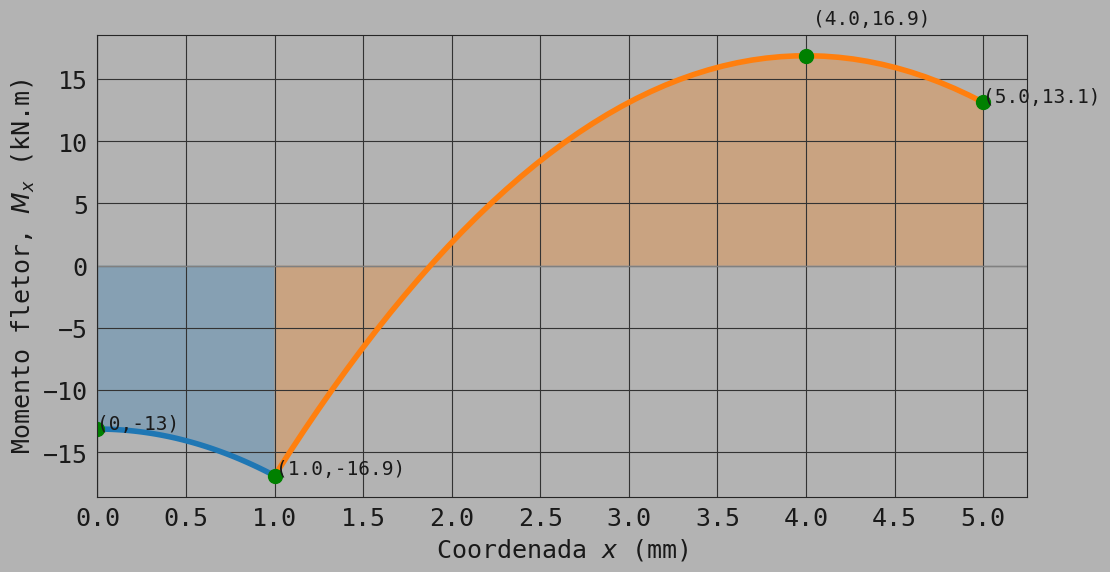

In [10]:
madim(MA_minMf)

In [11]:
def madimInter(MA):

    MAB_b = - MA - i1ab*(x-i2ab/i1ab)
    MAB_A_b = MAB_b.subs({(x,0)})
    MAB_B_b = MAB_b.subs({(x,dados.LAB)})
    MBC_b = MAB_B_b + iVbc
    MBC_B_b = MBC_b.subs({(x,dados.LAB)})
    MBC_C_b = MBC_b.subs({(x,dados.LAC)})
    yMAB_b = sy2array(MAB_b,xAB) #
    yMBC_b = sy2array(MBC_b,xBC) #
    Mmax_b = MBC_b.subs(x,xVbc0l)
    fig, ax = plt.subplots(figsize=(12,6))
    plt.axhline(linewidth=1,color=(.5, .5, .5))
    plt.axvline(linewidth=1,color=(.5, .5, .5))
    plt.plot(xAB,yMAB_b,linewidth=4)
    plt.fill_between(xAB,yMAB_b, alpha=.3)
    plt.plot(xBC,yMBC_b,linewidth=4)
    plt.fill_between(xBC,yMBC_b, alpha=.3)
    plt.xlabel(r'Coordenada $x$ (mm)')
    plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
    plt.plot(xAB[0],yMAB_b[0],'go',markersize=10)
    plt.text(xAB[0]*1.,yMAB_b[0],f'({xAB[0]:.0f},{yMAB_b[0]:.0f})',fontsize=fz)
    plt.text(xAB[-1]+.01,yMAB_b[-1]+.1,f'({xAB[-1]:.1f},{yMAB_b[-1]:.1f})',fontsize=fz)
    plt.plot(xBC[0],yMBC_b[0],'go',markersize=10)
    plt.plot(xBC[-1],yMBC_b[-1],'go',markersize=10)
    plt.text(xBC[-1]*1.,yMBC_b[-1]*1.,f'({xBC[-1]:.1f},{yMBC_b[-1]:.1f})',fontsize=fz)
    x0, y0 = xVbc0l, MBC_b.subs(x,xVbc0l)
    plt.text(x0*1.01,y0*1.15,f'({x0:.1f},{y0:.1f})',fontsize=14)
    plt.plot(x0,y0,'go',markersize=10)
    plt.xlim(0,dados.LAC*1.05)
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    xrang = np.round(np.arange(0,dados.LAC*1.1, 0.5),2)
    ax.set_xticks(xrang)
    ax.set_xticklabels([i for i in xrang])
    plt.grid(True)
    plt.show()

from ipywidgets import interactive

interactive_plot = interactive(madimInter, MA=(0, 20))
output = interactive_plot.children[-1]
output.layout.height = '800px'
interactive_plot

interactive(children=(IntSlider(value=10, description='MA', max=20), Output(layout=Layout(height='800px'))), _…

### Apêndice: Relações entre carga, esforço cortante e momento fletor

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P4/FormDiagramas.png"
width="400"/>

- Esforço transverso:
  
\begin{equation*}
V_D − V_C = − \int_{x_C}^{x_D} w(x) \mathrm{d} x
\end{equation*}


ou seja, $V_D − V_C$ = −(área sob a curva de carga entre C e D)

- Momento fletos:
  
\begin{equation*}
M_D − M_C = \int_{x_C}^{x_D} V(x) \mathrm{d} x
\end{equation*}


ou seja, $M_D − M_C$ = área sob a curva de esforço cortante entre C e D

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>